In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers 
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pyplot as plt

In [14]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat",
    "deer", "dog", "frog", "horse", "ship", "truck"
]

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


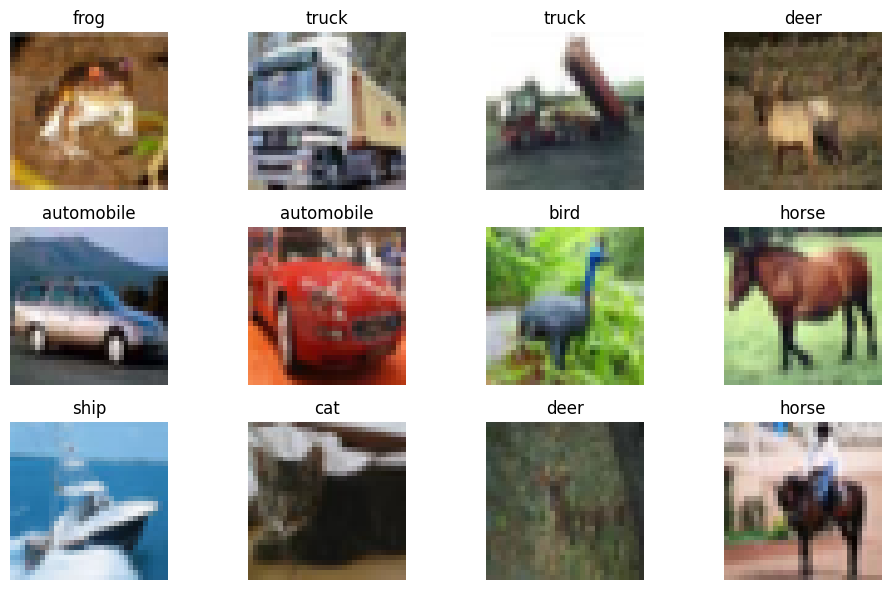

In [15]:
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])

    label = np.argmax(y_train[i])  
    plt.title(class_names[label])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc * 100:.4f}")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - accuracy: 0.4497 - loss: 1.5060 - val_accuracy: 0.5595 - val_loss: 1.2224
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.5933 - loss: 1.1476 - val_accuracy: 0.6170 - val_loss: 1.0710
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.6463 - loss: 1.0083 - val_accuracy: 0.6497 - val_loss: 0.9893
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6791 - loss: 0.9120 - val_accuracy: 0.6586 - val_loss: 0.9891
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 27ms/step - accuracy: 0.7071 - loss: 0.8368 - val_accuracy: 0.6719 - val_loss: 0.9321
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.7264 - loss: 0.7812 - val_accuracy: 0.6867 - val_loss: 0.8936
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.7432 - loss: 0.7307 - val_accuracy: 0.6986 - val_loss: 0.8916
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.7579 -

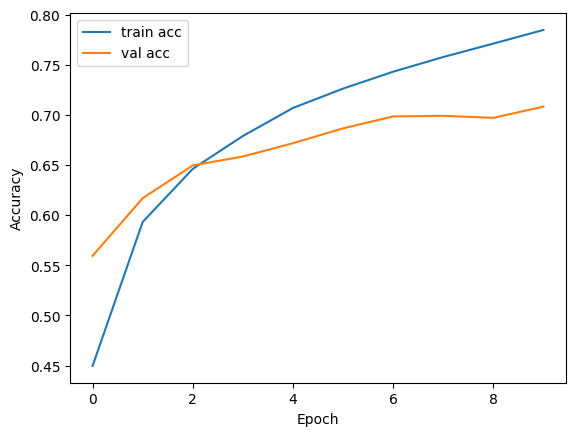

In [18]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [19]:
model.save("mnist_model_tf.keras")